
# Tutorial PUMA – Versión Optimizada




## Configuración del Entorno




In [1]:
# Cargo todas las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator, CubicSpline
import os
import glob

# Guía de pasos para usar PUMA para películas delgadas

## 1. Introducción
(https://www.ime.usp.br/~egbirgin/puma/#remarks)

PUMA es un software para estimar las constantes ópticas \( n \), \( k \) y el espesor de películas delgadas usando datos de transmitancia y/o reflectancia.

Este tutorial explicara cómo preparar los datos, correr PUMA desde la consola y entender sus parámetros principales.

---

## 2. Preparar el archivo de datos

PUMA requiere un archivo de texto con este formato:

- Primera línea: número de observaciones (por ejemplo, 100)
- Luego, cada línea contiene la longitud de onda (en nm) y la transmitancia (o reflectancia) en fracciones (0 a 1).


## Para compilar PUMA para una pelicula:

gcc -O4 -lm puma.c -o puma.exe

# Cómo usar PUMA para estimar el espesor y constantes ópticas de una película delgada

Para correr PUMA en un sistema de una sola película, se tiene que escribir en la terminal el siguiente comando:



```bash
puma FNAME NLAYERS SLAYER SUBSTRATE DATATYPE NOBS LAMBDAmin LAMBDAmax maxIT QUAD INIT THICKNESSmin THICKNESSmax THICKNESSstep INFLEmin INFLEmax INFLEstep N0ini N0fin N0step NFini NFfin NFstep K0ini K0fin K0step


donde las palabras en mayúsculas son parámetros que se describen a continuación:

- **FNAME**: nombre de la película que se está estudiando (sin espacios).  
  El archivo de entrada debe llamarse `FNAME-dat.txt`.  
  El archivo de salida será creado automáticamente como `FNAME-inf.txt`.

- **Formato del archivo de entrada** (`FNAME-dat.txt`):
  - La primera línea contiene el número de observaciones. Por ejemplo, si tienes 100 observaciones, el archivo tendrá 101 líneas.
  - Desde la segunda línea hasta la última, cada línea debe contener la longitud de onda y la transmitancia (o reflectancia o ambas). Esto significa que cada línea debe tener 2 o 3 números.
  - Los datos de transmitancia o reflectancia deben estar en fracciones, es decir, valores entre 0 y 1.  
    Si tus datos están en porcentaje (0 a 100), divídelos entre 100.

- **NLAYERS**: número total de capas del sistema (películas, substrato y las capas de aire inicial y final).  

- **SLAYER**: número de la capa que corresponde al substrato.  
  Para un sistema con: aire (capa 0), película (1), substrato (2) y aire (3), usa `SLAYER = 2`.

- **SUBSTRATE**: número que describe el substrato:  
  - 10: vidrio  
  - 20: silicio cristalino  
  - 30: cuarzo cristalino  
  - 40: portaobjetos de vidrio 
  - 50: borosilicato

- **DATATYPE**: tipo de dato. Usa:  
  - `T` para transmitancia  
  - `R` para reflectancia  
  - `B` para ambos

- **NOBS**: número de puntos usados en la optimización.  
  Se interpolan puntos equiespaciados dentro del intervalo `[LAMBDAmin, LAMBDAmax]`.  
  Se recomienda usar 100 si no se tiene experiencia.

- **LAMBDAmin**: límite inferior del rango de longitudes de onda para estimar las constantes ópticas.  
  Debe ser mayor o igual al menor valor de longitud de onda en el archivo de datos.

- **LAMBDAmax**: límite superior del rango.  
  Debe ser menor o igual al mayor valor de longitud de onda en el archivo de datos.  
  Obligatorio: `LAMBDAmax >= LAMBDAmin`.

- **maxIT**: número máximo de iteraciones del optimizador.  
  Por cada combinación fija de grosor y punto de inflexión se resuelve un problema de optimización no lineal.  
  Se recomienda usar:  
  - 3000 para primer intento  
  - 5000 para segundo intento  
  - 50000 para último intento

- **QUAD**: error cuadrático del mejor ajuste hasta el momento.  
  Solo se guardan soluciones con error menor que este valor.  
  En el primer intento, se usa un número muy grande, como `1e+100`.  
  Cuando se usa una estimación previa para guiar un nuevo intento, puede que no se encuentre una mejor solución. En ese caso, el grosor retornado es cero.
  


- **INIT**: entero que elige entre hacer la estimación inicial o usar la previa como punto de partida.  
  - Usa `0` para estimación inicial.  
  - Usa `9` para usar la estimación previa como inicial.  
  - Si se usa `9`, se ignoran los parámetros de estimación inicial (`N0ini`, `N0fin`, `N0step`, `NFini`, `NFfin`, `NFstep`, `K0ini`, `K0fin`, `K0step`).

- **THICKNESSmin**: límite inferior para el grosor de prueba.  
  - Junto con `THICKNESSmax` define el intervalo en que se busca el grosor real.  
  - Se necesita algún conocimiento previo para fijar este rango.

- **THICKNESSmax**: límite superior para el grosor de prueba.  
  - Debe cumplirse `THICKNESSmax >= THICKNESSmin`.  
  - Si `THICKNESSmax = THICKNESSmin`, entonces se asume que el grosor es conocido y solo se estiman las constantes ópticas. En este caso, `THICKNESSstep` se ignora.

- **THICKNESSstep**: paso para barrer los valores de grosor en el intervalo definido.

Los valores de grosor probados son:

$$
\text{THICKNESS} = \text{THICKNESSmin} + w \times \text{THICKNESSstep}, \quad w=0,1,2,...
$$

- **INFLEmin**: límite inferior del punto de inflexión del coeficiente de atenuación.  
  - En PUMA, el coeficiente de atenuación se aproxima por una función cóncava en $[\text{LAMBDAmin}, \text{INFLEPOINT}]$ y convexa en $[\text{INFLEPOINT}, \text{LAMBDAmax}]$.  
  - Define junto con `INFLEmax` el rango donde se busca ese punto de inflexión.  
  - Si no se tiene idea, poner `INFLEmin = LAMBDAmin`.

- **INFLEmax**: límite superior para el punto de inflexión.  
  - Debe cumplirse `INFLEmax >= INFLEmin`.  
  - Si no se sabe, pon `INFLEmax = LAMBDAmax`.  
  - Si no se sabe el punto exacto, poner `INFLEmax = INFLEmin` y el paso se ignora.

- **INFLEstep**: paso para barrer valores del punto de inflexión dentro del rango.

Los valores probados son:

$$
\text{INFLEPOINT} = \text{INFLEmin} + w \times \text{INFLEstep}, \quad w=0,1,2,...
$$

- **N0ini, N0fin, N0step, NFini, NFfin, NFstep**: parámetros para la estimación inicial del índice de refracción \( n \).

  La estimación inicial de \( n(\lambda) \) se hace con funciones lineales estrictamente decrecientes que van de:

  - $ N_0 $ en $\lambda = \text{LAMBDAmin}$, que varía entre `N0ini` y `N0fin` con paso `N0step`,  
  - a $ N_F$ en $\lambda = \text{LAMBDAmax}$, que varía entre `NFini` y `NFfin` con paso `NFstep`.

  Esto significa que las funciones iniciales son líneas que pasan por los pares:

$$
(\text{LAMBDAmin}, N_0), \quad (\text{LAMBDAmax}, N_F)
$$

con

$$
N_0 = \text{N0ini} + u \times \text{N0step}, \quad u = 0,1,2,...
$$

$$
N_F = \text{NFini} + v \times \text{NFstep}, \quad v = 0,1,2,...
$$

donde $ N_0 \in [\text{N0ini}, \text{N0fin}] $, $ N_F \in [\text{NFini}, \text{NFfin}] $, y $ N_0 > N_F $.


- Se necesita un conocimiento a priori del índice de refracción del material para fijar estos parámetros.

- **K0ini, K0fin, K0step**: estimaciones iniciales para el coeficiente de atenuación \( k \).  

  En este caso se usa una función lineal a tramos, con valores:  
  - $ K_0 $ en $\lambda = \text{LAMBDAmin}$,  
  - $ 0.1 \times K_0 $ en $\lambda = \text{LAMBDAmin} + 0.2 \times (\text{LAMBDAmax} - \text{LAMBDAmin})$,  
  - $ K_0 $ en $\lambda = \text{LAMBDAmax}$,  

  donde $ K_0 $ varía dentro del intervalo $[K0ini, K0fin]$ como:

  $$
  K_0 = K0ini + z \times K0step, \quad z = 0,1,2,...
  $$



# Sustratos soportados por PuMA

En PuMA, el parámetro `SUBSTRATE` define el índice de refracción de la capa base de la película según el material. Cada ID corresponde a un material específico y su rango de transparencia.

| ID | Material                      | Rango de λ (nm) |
|----|-------------------------------|----------------|
| 10 | Vidrio genérico                | 350 – 2000     |
| 20 | Silicio cristalino             | 1250 – 2600    |
| 30 | Cuarzo cristalino              | 200 – 1500     |
| 40 | Vidrio para portaobjetos (glass slides)      | 360 – 800      |
| 50 | Borosilicato                   | 300 – 2600     |
| 60 | Cuarzo amorfo                  | 200 – 1500     |

# Ejemplo para sistema de una sola película

Como se explicó antes, se puede correr PUMA haciendo una estimación inicial o usando una estimación previa como punto de partida, llamando a PUMA una, dos, tres o más veces según sea necesario. Esta flexibilidad combinada con una buena elección de parámetros de entrada da un grado alto de control.

Generalmente, con tres llamadas es suficiente. El procedimiento recomendado es:

1. En el primer intento, se elige un intervalo para los grosores de prueba alrededor de algún valor conocido.  
   Se fija el paso de grosor.  
   Se elige el intervalo para el punto de inflexión del coeficiente de atenuación igual al intervalo del espectro.

2. En el segundo intento, se estrecha el intervalo de grosores alrededor del grosor recuperado previamente.  
   Se disminuye el paso de grosor.  
   Y se hace lo mismo para el punto de inflexión del coeficiente de atenuación.  
   Además, se incrementa el número máximo de iteraciones.

3. En el tercer intento, se fija el grosor como el recuperado anteriormente.  
   Y se hace lo mismo para el punto de inflexión.  
   Y se vuelve a aumentar el máximo de iteraciones.


## Probando con datos del ITO

## Script para cambiar un archivo .dat al formato que se necesita para PuMA

In [ ]:

# Nombre del archivo original y del nuevo archivo
# Se usa la direción relativa, pero se puede usar la absoluta si se prefiere
input_file = "ITO_filtrado_400-1100.txt"  # cambiar esto al nombre del archivo
output_file = "ITO_filtrado_400-1100.txt"

# Lee los datos (dos columnas: longitud de onda y transmitancia, por ejemplo)
data = np.loadtxt(input_file)

# Reemplaza los valores negativos de transmitancia por un valor muy pequeño positivo, descomentar solo si no quiere quitar los negativos
#data[:, 1] = np.where(data[:, 1] < 0, 1e-10, data[:, 1])

# Elimina las filas con transmitancia negativa
data = data[data[:, 1] >= 0]

# Normaliza la transmitancia entre 0 y 1, descomentar solo si no esta normalizado
#data[:, 1] = data[:, 1] / 100.0

# Ordena las filas por longitud de onda (columna 0)
orden = np.argsort(data[:, 0])  # índices ordenados por longitud de onda
data = data[orden]              # reordena ambas columnas como pares

# Agregar la primera fila con el número de observaciones
n_obs = data.shape[0]
with open(output_file, "w") as f:
    f.write(f"{n_obs}\n")
    np.savetxt(f, data, fmt="%.3e %.3e")  # Guardar en notación científica

print(f"Archivo listo para PUMA: {output_file}")


Una vez tenemos nuestro archivo en un formato que acepta PUMA, tenemos que ejecutar la siguiente linea de codigo

```bash
./puma.exe ITO_data_curated 4 2 70 T 100 0400 1000 3000 1e+100 0 0140 0170 1 0300 1100 50 1.6 2.4 0.05 1.5 2.2 0.05 0.00 0.40 0.05 > ITO_firstcall.txt





## Parámetros First Call

| Parámetro | Valor | Significado |
|-----------|-------|------------|
| `FNAME` | ITO_data_curated | Archivo de entrada que contiene los datos del film. |
| `NLAYERS` | 4 | Número total de capas: aire inicial + film + sustrato + aire final. |
| `SLAYER` | 2 | Número de la capa de interés: 0 → aire inicial, 1 → film, 2 → sustrato, 3 → aire final. |
| `SUBSTRATE` | 70 | Código del sustrato, en este caso el soda lime glass que agregué. |
| `DATATYPE` | T | Tipo de medida: `T` para transmitancia, `R` para reflectancia o `B` para ambos. |
| `NOBS` | 100 | Número de observaciones o puntos de longitud de onda. |
| `LAMBDAmin` | 400 | Longitud de onda mínima (nm) considerada para ajuste. |
| `LAMBDAmax` | 1000 | Longitud de onda máxima (nm) considerada para ajuste. |
| `MAXIT` | 3000 | Número máximo de iteraciones para el ajuste (lo mande en cluster, para local reducir el numero). |
| `QUAD` | 1e+100 | Cota máxima del error cuadrático (muy alta para no limitar). |
| `INIT` | 0 | Se realiza estimación inicial. |
| `THICKNESSmin` | 165 | Espesor mínimo de la capa (nm) para el ajuste. |
| `THICKNESSmax` | 175 | Espesor máximo de la capa (nm) para el ajuste. |
| `THICKNESSstep` | 1 | Paso de espesor para el barrido de ajuste. |
| `INFLEmin` | 300 | Longitud de onda mínima para buscar punto de inflexión. |
| `INFLEmax` | 1100 | Longitud de onda máxima para punto de inflexión. |
| `INFLEstep` | 50 | Paso en la búsqueda del punto de inflexión. |
| `N0ini` | 1.6 | Valor mínimo de índice de refracción de la capa inicial. |
| `N0fin` | 2.4 | Valor máximo de índice de refracción de la capa inicial. |
| `N0step` | 0.05 | Paso de n para barrido de ajuste. |
| `NFini` | 1.5 | Valor mínimo de índice de refracción de la capa final. |
| `NFfin` | 2.2 | Valor máximo de índice de refracción de la capa final. |
| `NFstep` | 0.05 | Paso de n de la capa final. |
| `K0ini` | 0.00 | Valor mínimo de coeficiente de absorción de la capa inicial. |
| `K0fin` | 0.40 | Valor máximo de coeficiente de absorción de la capa inicial. |
| `K0step` | 0.05 | Paso de κ para barrido de ajuste. |



Del first call, revisamos el -inf.txt y de ahí obtenemos el espesor estimado, punto de inflexión, y error cuadratico y mandamos a hacer el second call.
Inicialmente salió Espesor estimado = 166 nm, Punto de inflexión = 300 nm y Error cuadrático = 2.989977e-02
```bash
./puma.exe ITO_data_curated 4 2 70 T 100 0300 1100 5000 2.989977e-02 9 0120 0200 1 0300 0300 100 > ITO_secondcall.txt




## Parámetros Second Call:

| Parámetro | Valor | Explicación |
|-----------|-------|-------------|
| `FNAME` | ITO_data_curated | Nombre del archivo de datos que contiene la transmitancia medida. |
| `NLAYERS` | 4 | Número de capas (aire inicial + film + sustrato + aire final). |
| `SLAYER` | 2 | Índice de la capa a ajustar (la película es layer 1, sustrato layer 2). |
| `SUBSTRATE` | 10 | Identificador del sustrato usado (por ejemplo vidrio). |
| `DATATYPE` | T | Tipo de dato a ajustar: Transmittancia. |
| `NOBS` | 100 | Número de puntos de observación usados en el ajuste. |
| `LAMBDAmin` | 300 | Longitud de onda mínima en nm considerada para el ajuste. |
| `LAMBDAmax` | 1100 | Longitud de onda máxima en nm considerada para el ajuste. |
| `MAXIT` | 5000 | Número máximo de iteraciones del algoritmo de ajuste. |
| `QUAD` | 2.989977e-02| Error cuadrático obtenido en el first call, usado como referencia. |
| `INIT` | 9 | Indica que es un segundo call refinando los parámetros. |
| `THICKNESSmin` | 120 | Espesor mínimo de la película (nm) en este barrido. |
| `THICKNESSmax` | 200 | Espesor máximo de la película (nm). |
| `THICKNESSstep` | 1 | Paso para el barrido de espesor. |
| `INFLEmin` | 300 | Punto de inflexión mínimo para α(λ) (nm). |
| `INFLEmax` | 300 | Punto de inflexión máximo (igual al mínimo, es fijo). |
| `INFLEstep` | 100 | Paso para el barrido de puntos de inflexión (aquí no importa, ya que min=max). |


Ahora para el Third Call, obtuvimos anteriormente que Espesor estimado = 166 nm, Punto de inflexión = 300 nm y Error cuadrático = 2.989977e-02, vamos a relajar un poco el error, porque ya deporsi es muy bajo y le va a costar encontrar un mejor ajuste
```bash
./puma.exe ITO_data_curated 4 2 70 T 100 0300 1100 500000 3e-02 9 0165 0167 1 0295 0305 1 > ITO_thirdcall.txt


Parámetros Third Call:

| Parámetro | Valor | Explicación |
|-----------|-------|-------------|
| `FNAME` | ITO_data_curated | Nombre del archivo de datos que contiene la transmitancia medida. |
| `NLAYERS` | 4 | Número de capas (aire inicial + película + sustrato + aire final). |
| `SLAYER` | 2 | Índice de la capa a ajustar (la película es layer 1, sustrato layer 2). |
| `SUBSTRATE` | 70 | Identificador del sustrato usado (ej. vidrio ). |
| `DATATYPE` | T | Tipo de dato a ajustar: Transmittancia. |
| `NOBS` | 100 | Número de puntos de observación usados en el ajuste. |
| `LAMBDAmin` | 300 | Longitud de onda mínima en nm considerada para el ajuste. |
| `LAMBDAmax` | 1100 | Longitud de onda máxima en nm considerada para el ajuste. |
| `MAXIT` | 50000 | Número máximo de iteraciones del algoritmo de ajuste (muy alto para refinar la solución). |
| `QUAD` | 3e-02 | Error cuadrático obtenido del second call, usado como referencia. |
| `INIT` | 9 | Indica que es un tercer call refinando los parámetros anteriores. |
| `THICKNESSmin` | 165 | Espesor mínimo de la película (nm) en este barrido. |
| `THICKNESSmax` | 167 | Espesor máximo de la película (nm), aquí fijado. |
| `THICKNESSstep` | 100 | Paso para el barrido de espesor (irrelevante al ser min=max). |
| `INFLEmin` | 295 | Punto de inflexión mínimo para α(λ) (nm). |
| `INFLEmax` | 303 | Punto de inflexión máximo (fijo). |
| `INFLEstep` | 1 | Paso para el barrido de puntos de inflexión (irrelevante al ser min=max). |


## Aplicando Filtro Golay a los datos

In [ ]:

# === 1. Leer archivo (ignorando la primera fila) ===
data = np.loadtxt('ITO_data_curated_400-1100.txt', skiprows=1)
longitud_onda = data[:, 0]
transmitancia = data[:, 1]

# === 2. Aplicar filtro Savitzky–Golay ===
window_size = 61  # impar
poly_order = 3
T_filtrada = savgol_filter(transmitancia, window_size, poly_order)

# === 3. Crear figura interactiva ===
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=longitud_onda,
    y=transmitancia,
    mode='lines',
    name='Datos originales',
    line=dict(color='rgba(100,100,255,0.5)')
))

fig.add_trace(go.Scatter(
    x=longitud_onda,
    y=T_filtrada,
    mode='lines',
    name='Filtrado (Savitzky–Golay)',
    line=dict(color='red', width=2)
))

# === 4. Personalizar diseño ===
fig.update_layout(
    title='Transmitancia de ITO (Filtro Savitzky–Golay)',
    xaxis_title='Longitud de onda (nm)',
    yaxis_title='Transmitancia (%)',
    #template='plotly_dark',  # opcional: "plotly", "simple_white", "ggplot2", etc.
    legend=dict(x=0.02, y=0.98)
)

fig.show()

# === 5. Guardar datos filtrados (opcional) ===
salida = np.column_stack((longitud_onda, T_filtrada))
np.savetxt('ITO_filtrado_400-1100.txt', salida,
           fmt='%.6f', comments='')



## Grafica resultados de PUMA

Puntos n/κ  : 150
Puntos T sim: 150
Puntos T exp: 551
RMSE relativo : 0.08 %
MAPE          : 0.06 %


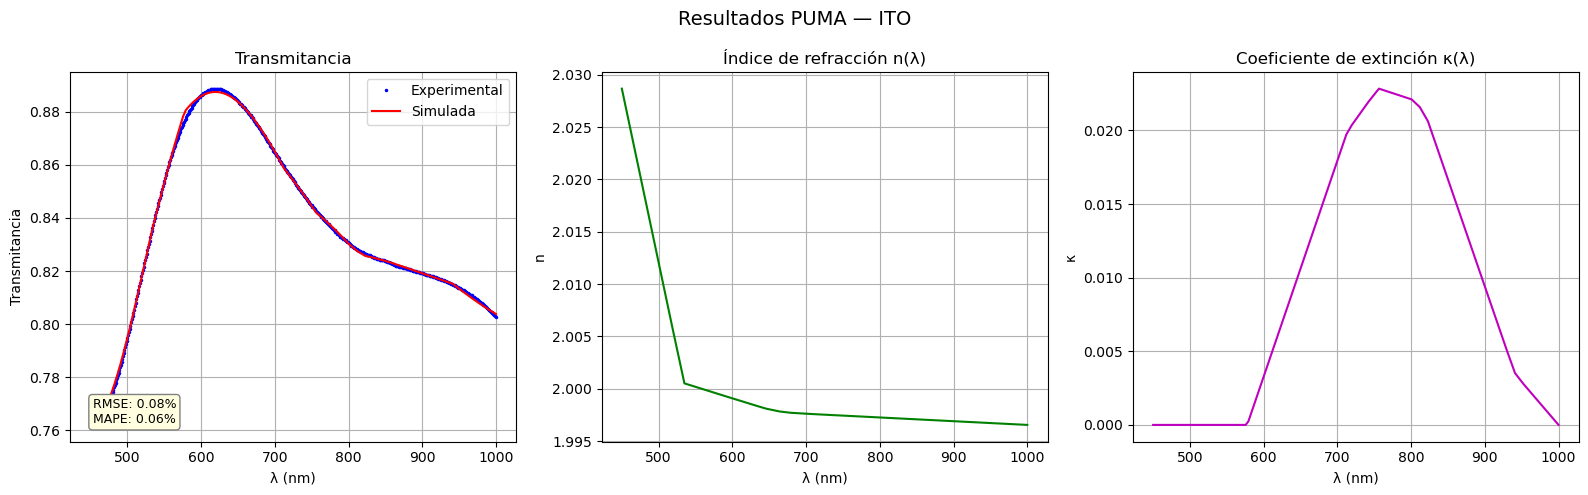

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# === Archivos ===
filename_sim = r"C:\Users\Gabo\Computacional\LabAvanzadoII\ITO_result_PUMA\ITO_s70_450-1000-2.txt"
filename_exp = r"C:\Users\Gabo\Computacional\LabAvanzadoII\ITO_filtrado\ITO_filtrado_450-1000.txt"

# === Parser por secciones ===
block_nk = []   # λ, n, kappa
block_t  = []   # λ, T simulada

current_section = None

with open(filename_sim, "r") as f:
    for line in f:
        line_strip = line.strip()

        if "REFRACTIVE INDICES AND ABSORPTION" in line_strip:
            current_section = "nk"
            continue
        elif "TRANSMITTANCE WITH THE ESTIMATED" in line_strip:
            current_section = "t"
            continue

        if not line_strip or line_strip.startswith("lambda") or line_strip.startswith("Film"):
            continue

        try:
            vals = list(map(float, line_strip.split()))
            if current_section == "nk" and len(vals) == 3:
                block_nk.append(vals)
            elif current_section == "t" and len(vals) == 2:
                block_t.append(vals)
        except:
            continue

block_nk = np.array(block_nk)
block_t  = np.array(block_t)

# === Extraer variables ===
lambda1 = block_nk[:, 0]
n       = block_nk[:, 1]
kappa   = block_nk[:, 2]

lambda2 = block_t[:, 0]
T_sim   = block_t[:, 1]

# === Cargar experimental ===
exp_data   = np.loadtxt(filename_exp, skiprows=1)
lambda_exp = exp_data[:, 0]
T_exp      = exp_data[:, 1]

print(f"Puntos n/κ  : {len(lambda1)}")
print(f"Puntos T sim: {len(lambda2)}")
print(f"Puntos T exp: {len(lambda_exp)}")

# === Interpolación para errores ===
interp_T     = interp1d(lambda2, T_sim, kind='linear', fill_value="extrapolate")
T_sim_interp = interp_T(lambda_exp)

rmse         = np.sqrt(np.mean((T_sim_interp - T_exp)**2))
percent_rmse = rmse / np.mean(T_exp) * 100
mape         = np.mean(np.abs(T_sim_interp - T_exp) / T_exp) * 100

print(f"RMSE relativo : {percent_rmse:.2f} %")
print(f"MAPE          : {mape:.2f} %")

# === Gráficas ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Resultados PUMA — ITO", fontsize=14)

# 1. Transmitancia
axes[0].plot(lambda_exp, T_exp,  'b.', markersize=3, label="Experimental")
axes[0].plot(lambda2,    T_sim,  'r-', linewidth=1.5, label="Simulada")
axes[0].set_xlabel("λ (nm)")
axes[0].set_ylabel("Transmitancia")
axes[0].set_title("Transmitancia")
axes[0].legend()
axes[0].grid(True)
axes[0].annotate(f"RMSE: {percent_rmse:.2f}%\nMAPE: {mape:.2f}%",
                 xy=(0.05, 0.05), xycoords="axes fraction", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

# 2. n vs λ
axes[1].plot(lambda1, n, 'g-', linewidth=1.5)
axes[1].set_xlabel("λ (nm)")
axes[1].set_ylabel("n")
axes[1].set_title("Índice de refracción n(λ)")
axes[1].grid(True)

# 3. κ vs λ
axes[2].plot(lambda1, kappa, 'm-', linewidth=1.5)
axes[2].set_xlabel("λ (nm)")
axes[2].set_ylabel("κ")
axes[2].set_title("Coeficiente de extinción κ(λ)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import interp1d

# === Archivos ===
filename_sim = r"C:\Users\Gabo\Computacional\LabAvanzadoII\ITO_result_PUMA\ITO_s70_535-1000.txt"
filename_exp = r"C:\Users\Gabo\Computacional\LabAvanzadoII\ITO_filtrado\ITO_filtrado_535-1000.txt"

# === Parser por secciones usando encabezados como marcadores ===
block_nk = []   # λ, n, kappa
block_t  = []   # λ, T simulada

current_section = None

with open(filename_sim, "r") as f:
    for line in f:
        line_strip = line.strip()

        # Detectar inicio de sección
        if "REFRACTIVE INDICES AND ABSORPTION" in line_strip:
            current_section = "nk"
            continue
        elif "TRANSMITTANCE WITH THE ESTIMATED" in line_strip:
            current_section = "t"
            continue

        # Saltar líneas de encabezado o vacías
        if not line_strip or line_strip.startswith("lambda") or line_strip.startswith("Film"):
            continue

        # Parsear línea numérica
        try:
            vals = list(map(float, line_strip.split()))
            if current_section == "nk" and len(vals) == 3:
                block_nk.append(vals)
            elif current_section == "t" and len(vals) == 2:
                block_t.append(vals)
        except:
            continue

block_nk = np.array(block_nk)
block_t  = np.array(block_t)

# === Extraer variables ===
lambda_nk = block_nk[:, 0]
n         = block_nk[:, 1]
kappa     = block_nk[:, 2]

lambda_t  = block_t[:, 0]
T_sim     = block_t[:, 1]

print(f"Puntos n/κ  : {len(lambda_nk)}")
print(f"Puntos T sim: {len(lambda_t)}")

# === Cargar datos experimentales ===
exp_data   = np.loadtxt(filename_exp, skiprows=1)
lambda_exp = exp_data[:, 0]
T_exp      = exp_data[:, 1]

# === Interpolación de T_sim a puntos experimentales ===
interp_T     = interp1d(lambda_t, T_sim, kind='linear', fill_value="extrapolate")
T_sim_interp = interp_T(lambda_exp)

# === Calcular errores ===
rmse          = np.sqrt(np.mean((T_sim_interp - T_exp)**2))
percent_rmse  = rmse / np.mean(T_exp) * 100
mape          = np.mean(np.abs(T_sim_interp - T_exp) / T_exp) * 100

print(f"RMSE relativo : {percent_rmse:.2f} %")
print(f"MAPE          : {mape:.2f} %")

# === Coeficiente de absorción α ===
h_c   = 1240                                      # eV·nm
E     = h_c / lambda_nk                           # eV
alpha = 4 * np.pi * kappa / (lambda_nk * 1e-7)   # cm⁻¹

# === Función para guardar HTML ===
def save_plot_html(fig, fname_base):
    fig.write_html(f"{fname_base}.html")
    fig.show()

# === 1. Transmitancia ===
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=lambda_exp, y=T_exp,  mode="markers", name="Experimental"))
fig1.add_trace(go.Scatter(x=lambda_t,   y=T_sim,  mode="lines",   name="Simulado"))
fig1.add_annotation(
    text=f"RMSE: {percent_rmse:.2f}%   MAPE: {mape:.2f}%",
    xref="paper", yref="paper", x=0.05, y=0.95,
    showarrow=False, font=dict(size=12, color="black"),
    bgcolor="rgba(255,255,255,0.7)", bordercolor="black", borderwidth=1
)
fig1.update_layout(title="Transmitancia Experimental vs Simulada",
                   xaxis_title="Longitud de onda (nm)", yaxis_title="Transmitancia")
fig1.show()

# === 2. Índice de refracción n vs λ ===
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=lambda_nk, y=n, mode="lines", name="n"))
fig2.update_layout(title="Índice de Refracción n vs λ",
                   xaxis_title="Longitud de onda (nm)", yaxis_title="n")
fig2.show()

# === 3. Coeficiente de extinción κ vs λ ===
fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=lambda_nk, y=kappa, mode="lines", name="κ"))
fig3.update_layout(title="Coeficiente de Extinción κ vs λ",
                   xaxis_title="Longitud de onda (nm)", yaxis_title="κ")
fig3.show()

Puntos n/κ  : 100
Puntos T sim: 100
RMSE relativo : 0.07 %
MAPE          : 0.04 %


## Codigo para generar archivos de initial seed y demás de PUMA para usar en el codigo de Fortran

In [2]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def generar_archivos(input_exp, input_sim, output_dy="Dy_T", output_seed="DATANK0_DY"):
    # =========================
    # 1. Crear Dy_T (experimental)
    # =========================
    wl_exp, T_exp = [], []

    with open(input_exp, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:  # saltar encabezado
            if line.strip():
                parts = line.split()
                wl_exp.append(float(parts[0]))
                T_exp.append(float(parts[1]))

    wl_exp = np.array(wl_exp)
    T_exp = np.array(T_exp)

    with open(output_dy, 'w') as f:
        for w, t in zip(wl_exp, T_exp):
            f.write(f"{w:.2f}\t{t:.5f}\n")

    print(f"✔ Dy_T creado con {len(wl_exp)} puntos")

    # =========================
    # 2. Leer simulación (n, k)
    # =========================
    wl, n_vals, k_vals = [], [], []

    with open(input_sim, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:
                try:
                    wl.append(float(parts[0]))
                    n_vals.append(float(parts[1]))
                    k_vals.append(float(parts[2]))
                except:
                    continue

    wl = np.array(wl)
    n_vals = np.array(n_vals)
    k_vals = np.array(k_vals)

    if len(wl) == 0:
        raise ValueError("No se pudieron leer datos de simulación")

    # =========================
    # 3. Interpolar a malla experimental
    # =========================
    n_interp = PchipInterpolator(wl, n_vals)(wl_exp)
    k_interp = PchipInterpolator(wl, k_vals)(wl_exp)

    # Restricción física
    k_interp = np.clip(k_interp, 0.0, None)

    # =========================
    # 4. Crear DATANK0_DY
    # =========================
    with open(output_seed, "w") as f:
        for w, n_v, k_v in zip(wl_exp, n_interp, k_interp):
            f.write(f"{w:.6f} {n_v:.6f} {k_v:.6f}\n")

    print(f"✔ DATANK0_DY creado con {len(wl_exp)} puntos")


# =========================
# USO
# =========================

generar_archivos(
    input_exp=r"C:\Users\Gabo\Computacional\LabAvanzadoII\ITO_filtrado\ITO_filtrado_450-1000.txt",
    input_sim=r"C:\Users\Gabo\Computacional\LabAvanzadoII\ITO_result_PUMA\ITO_s70_450-1000-1.txt"
)

✔ Dy_T creado con 551 puntos
✔ DATANK0_DY creado con 551 puntos


## Crea tabla final de resultados

Corre en la terminal el siguiente comando:

```bash
python run_windows_pipeline.py
```

## Graficas de n y k finales

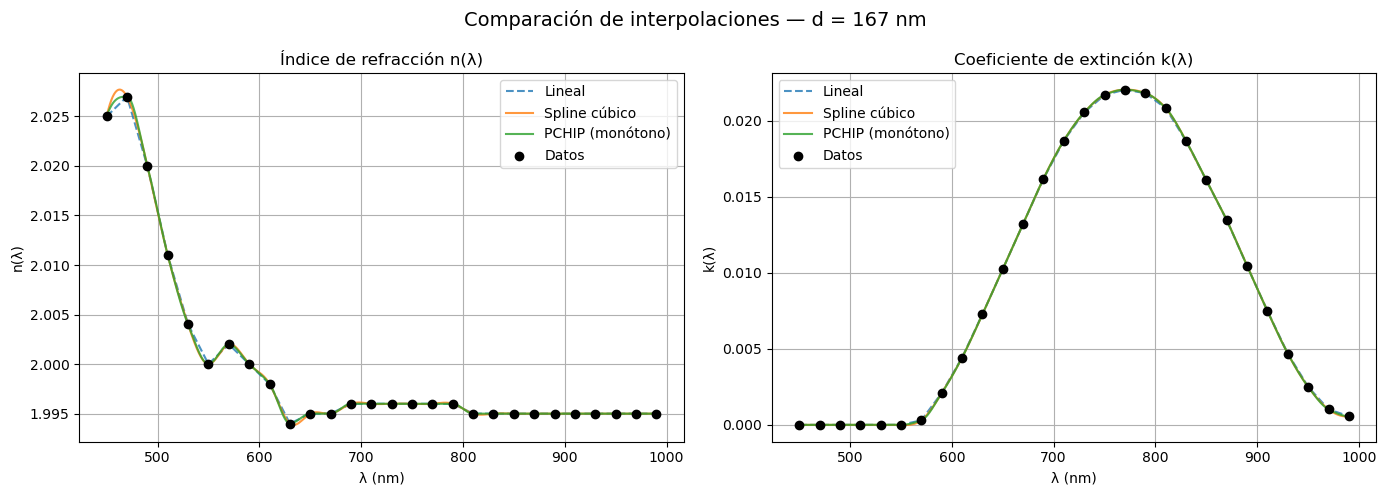

In [5]:
# Una vez generados n y k del paso anterior, se pueden graficar e interpolar con el siguiente código:

# ============================================
# 1. Cargar datos
# ============================================
data = np.loadtxt("tabla_final_nk.txt")

lam    = data[:, 0]
n_vals = data[:, 1]
k_vals = data[:, 2]

lam_fine = np.linspace(lam.min(), lam.max(), 2000)

# ============================================
# 2. Interpoladores
# ============================================
lin_n   = interp1d(lam, n_vals, kind='linear')
lin_k   = interp1d(lam, k_vals, kind='linear')
cs_n    = CubicSpline(lam, n_vals)
cs_k    = CubicSpline(lam, k_vals)
pchip_n = PchipInterpolator(lam, n_vals)
pchip_k = PchipInterpolator(lam, k_vals)

# ============================================
# 3. Evaluar
# ============================================
n_lin   = lin_n(lam_fine)
k_lin   = lin_k(lam_fine)
n_cs    = cs_n(lam_fine)
k_cs    = cs_k(lam_fine)
n_pchip = pchip_n(lam_fine)
k_pchip = pchip_k(lam_fine)

# ============================================
# 4. Figura combinada
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de interpolaciones — d = 167 nm", fontsize=14)

# --- n(λ) ---
ax1.plot(lam_fine, n_lin,   '--', label="Lineal",           alpha=0.8)
ax1.plot(lam_fine, n_cs,          label="Spline cúbico",    alpha=0.8)
ax1.plot(lam_fine, n_pchip,       label="PCHIP (monótono)", alpha=0.8)
ax1.scatter(lam, n_vals, color='black', zorder=4, label="Datos")
ax1.set_xlabel("λ (nm)")
ax1.set_ylabel("n(λ)")
ax1.set_title("Índice de refracción n(λ)")
ax1.legend()
ax1.grid(True)

# --- k(λ) ---
ax2.plot(lam_fine, k_lin,   '--', label="Lineal",           alpha=0.8)
ax2.plot(lam_fine, k_cs,          label="Spline cúbico",    alpha=0.8)
ax2.plot(lam_fine, k_pchip,       label="PCHIP (monótono)", alpha=0.8)
ax2.scatter(lam, k_vals, color='black', zorder=4, label="Datos")
ax2.set_xlabel("λ (nm)")
ax2.set_ylabel("k(λ)")
ax2.set_title("Coeficiente de extinción k(λ)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Calculo de transmitancia apartir de n y k

No se encontró espesor en el nombre del archivo. Usando d = 167.0 nm
Error RMS              = 0.002731
Error porcentual medio = 0.27 %
Error porcentual max   = 0.73 %
T_calc max             = 0.8885


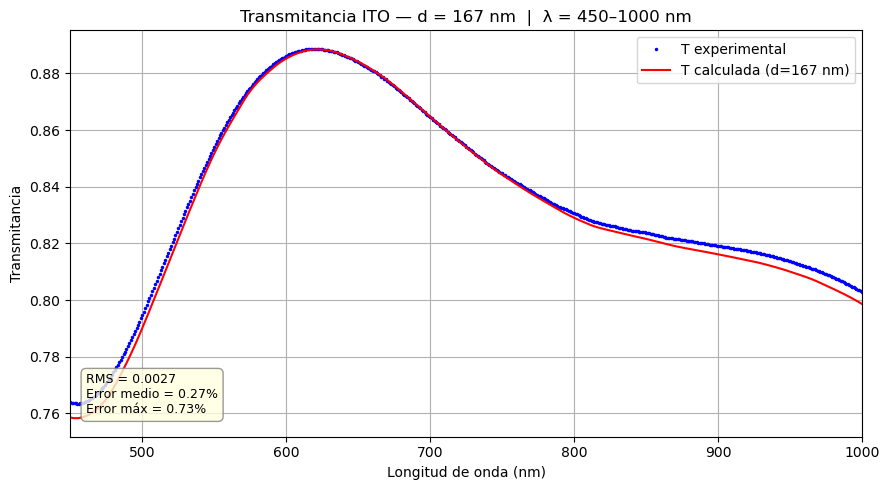

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import os
import re

# ==========================================================
# CONFIGURACIÓN
# ==========================================================
archivo_exp = r"C:\Users\Gabo\Computacional\LabAvanzadoII\Dy_T"
archivo_nk  = r"C:\Users\Gabo\Computacional\LabAvanzadoII\tabla_final_nk.txt"

LAMBDA_MIN = 450.0
LAMBDA_MAX = 1000.0

# ==========================================================
# 1. EXTRAER ESPESOR DEL NOMBRE DEL ARCHIVO
# ==========================================================
nombre = os.path.basename(archivo_nk)          # tabla_final_nk_164.txt
match  = re.search(r"(\d+(?:\.\d+)?)", nombre) # busca el primer número

if match:
    d_nm = float(match.group(1))
    print(f"Espesor extraído del nombre '{nombre}': d = {d_nm} nm")
else:
    d_nm = 167.0
    print(f"No se encontró espesor en el nombre del archivo. Usando d = {d_nm} nm")

# ==========================================================
# 2. CARGAR DATOS EXPERIMENTALES
# ==========================================================
exp = np.loadtxt(archivo_exp)

lam_exp = exp[:, 0]
T_exp   = exp[:, 1]

mask    = (lam_exp >= LAMBDA_MIN) & (lam_exp <= LAMBDA_MAX)
lam_exp = lam_exp[mask]
T_exp   = T_exp[mask]

# ==========================================================
# 3. CARGAR n, k DEL ITO
# ==========================================================
nk     = np.loadtxt(archivo_nk)
lam_nk = nk[:, 0]
n_vals = nk[:, 1]
k_vals = nk[:, 2]

n_interp = PchipInterpolator(lam_nk, n_vals)
k_interp = PchipInterpolator(lam_nk, k_vals)

# ==========================================================
# 4. DISPERSIÓN SLG – CAUCHY (λ en µm)
# ==========================================================
def n_slg_cauchy(lambda_nm):
    lam_um = lambda_nm / 1000.0
    return 1.5130 - 0.003169 * lam_um**2 + 0.003962 * lam_um**(-2)

# ==========================================================
# 5. MODELO DE TRANSMITANCIA
#    aire / ITO / SLG(grueso) / aire
# ==========================================================
def T_model(lambda_nm, d_ito_nm):
    lam = np.asarray(lambda_nm)
    n0  = 1.0                                    # aire incidente
    n3  = 1.0                                    # aire salida
    n1  = n_interp(lam) + 1j * k_interp(lam)    # ITO complejo
    n2  = n_slg_cauchy(lam)                      # SLG real

    # Interferencia coherente en ITO
    beta = 2.0 * np.pi * n1 * d_ito_nm / lam

    r01 = (n0 - n1) / (n0 + n1)
    r12 = (n1 - n2) / (n1 + n2)
    t01 = 2.0 * n0  / (n0 + n1)
    t12 = 2.0 * n1  / (n1 + n2)

    t_ito = (t01 * t12 * np.exp(1j * beta)) / \
            (1.0 + r01 * r12 * np.exp(2j * beta))

    T_ito_to_glass = (np.real(n2) / n0) * np.abs(t_ito)**2

    # Reflexión posterior del vidrio (incoherente)
    R_back  = ((n2 - n3) / (n2 + n3))**2
    T_total = T_ito_to_glass * (1 - R_back) / (1 - R_back**2)

    return np.real(T_total)

# ==========================================================
# 6. CALCULAR Y EVALUAR
# ==========================================================
T_calc = T_model(lam_exp, d_nm)

RMS  = np.sqrt(np.mean((T_calc - T_exp)**2))
MAPE = np.mean(np.abs((T_calc - T_exp) / T_exp)) * 100   # error porcentual promedio
MAXE = np.max(np.abs((T_calc - T_exp) / T_exp)) * 100    # error porcentual máximo

print(f"Error RMS              = {RMS:.6f}")
print(f"Error porcentual medio = {MAPE:.2f} %")
print(f"Error porcentual max   = {MAXE:.2f} %")
print(f"T_calc max             = {np.max(T_calc):.4f}")

# ==========================================================
# 7. GRÁFICA
# ==========================================================
plt.figure(figsize=(9, 5))
plt.title(f"Transmitancia ITO — d = {d_nm:.0f} nm  |  λ = {LAMBDA_MIN:.0f}–{LAMBDA_MAX:.0f} nm",
          fontsize=12)
plt.plot(lam_exp, T_exp,   'b.', markersize=3,   label="T experimental")
plt.plot(lam_exp, T_calc,  'r-', linewidth=1.5,  label=f"T calculada (d={d_nm:.0f} nm)")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Transmitancia")
plt.xlim(LAMBDA_MIN, LAMBDA_MAX)
plt.legend()
plt.annotate(
    f"RMS = {RMS:.4f}\nError medio = {MAPE:.2f}%\nError máx = {MAXE:.2f}%",
    xy=(0.02, 0.05), xycoords='axes fraction',
    fontsize=9, verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.8)
)
plt.grid(True)
plt.tight_layout()
plt.show()

# Modelo Óptico del Sistema

Se reconstruyó la transmitancia teórica del sistema:

aire / ITO / SLG / aire

a partir de los valores espectrales de $n(\lambda)$ y $k(\lambda)$ obtenidos mediante el procedimiento híbrido.

---

## 1. Índice de refracción complejo

El ITO se describe mediante un índice complejo:

$$
\tilde{n}(\lambda) = n(\lambda) + i\,k(\lambda)
$$

donde:

- $n(\lambda)$ controla la velocidad de fase.
- $k(\lambda)$ describe la absorción del material.

El coeficiente de absorción es:

$$
\alpha(\lambda) = \frac{4\pi k(\lambda)}{\lambda}
$$

---

## 2. Interferencia en película delgada

Para una película de espesor $d$, la fase óptica acumulada es:

$$
\beta = \frac{2\pi}{\lambda}\,\tilde{n}_1\, d
$$

En incidencia normal, los coeficientes de Fresnel son:

$$
r_{ij} = \frac{n_i - n_j}{n_i + n_j}
$$

$$
t_{ij} = \frac{2 n_i}{n_i + n_j}
$$

La amplitud transmitida a través de la película es:

$$
t =
\frac{
t_{01} t_{12} e^{i\beta}
}{
1 + r_{01} r_{12} e^{2 i \beta}
}
$$

La transmitancia energética es:

$$
T =
\frac{n_2}{n_0}
\left| t \right|^2
$$

---

## 3. Dispersión del sustrato (SLG)

El índice del vidrio se modeló mediante la ecuación de Cauchy:

$$
n(\lambda) =
1.5130
- 0.003169\,\lambda^2
+ 0.003962\,\lambda^{-2}
$$

donde $\lambda$ está expresada en micrómetros ($\mu m$).

El vidrio se considera no absorbente en el rango visible.

---

## 4. Tratamiento del vidrio grueso

El SLG se considera suficientemente grueso como para:

- No producir interferencia coherente.
- Sí generar reflexión en la cara posterior.

Por ello se incluyó el efecto incoherente de la reflexión aire/vidrio posterior.

---

## 5. Métrica de comparación

El error cuadrático medio utilizado fue:

$$
\mathrm{RMS} =
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
T_{\text{calc},i}
-
T_{\text{exp},i}
\right)^2
}
$$

In [24]:

# ============================================================
# CONFIGURACIÓN
# ============================================================
input_file  = "tabla_final_nk_167.txt"
output_file = "tabla_final_nk_interp_167.txt"
# ============================================================

# Leer archivo
data = np.loadtxt(input_file)
wl = data[:, 0]
n  = data[:, 1]
k  = data[:, 2]

# Interpolación PCHIP (no oscila, ideal para datos ópticos)
interp_n = PchipInterpolator(wl, n)
interp_k = PchipInterpolator(wl, k)

wl_new = np.arange(450, 1001, 1)
n_new  = interp_n(wl_new)
k_new  = np.clip(interp_k(wl_new), 0.0, None)  # k >= 0 siempre

# Guardar con el mismo formato
with open(output_file, "w") as f:
    for wl_i, n_i, k_i in zip(wl_new, n_new, k_new):
        f.write(f"{wl_i:.6f}   {n_i:.6f}   {k_i:.6f}\n")

print(f"✓ Generado: {output_file}  ({len(wl_new)} puntos, 450–1000 nm)")

✓ Generado: tabla_final_nk_interp_167.txt  (551 puntos, 450–1000 nm)


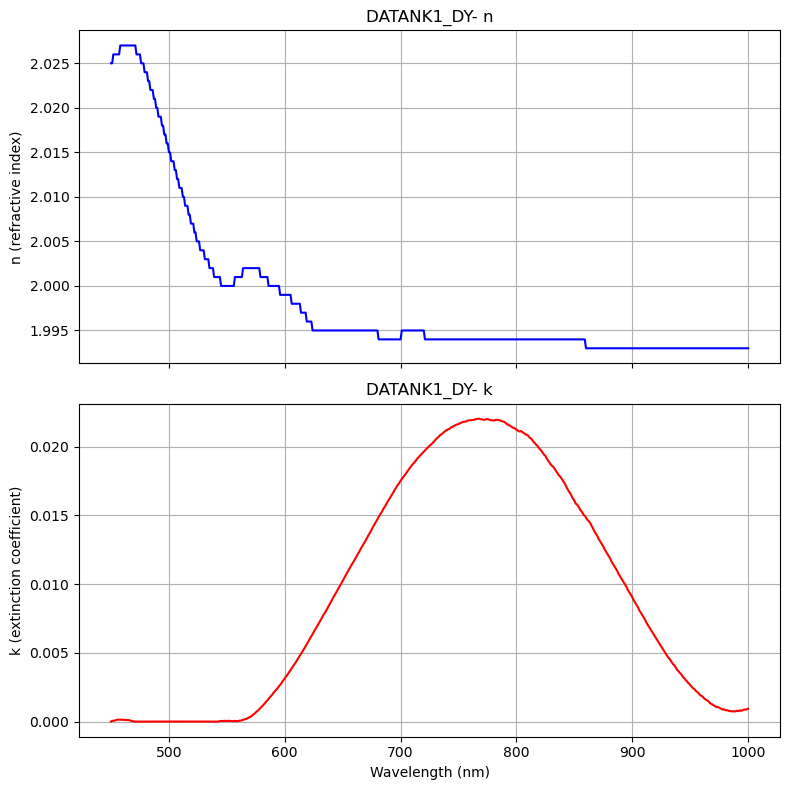

In [25]:
# Grafica resultados de FORTRAN

#filename = "DATANK0_DY" #para initial seed
filename = "DATANK1_DY" #Para resultado

# Leer datos
data = np.loadtxt(filename)
wl = data[:, 0]   # longitudes de onda
n = data[:, 1]    # índice de refracción
k = data[:, 2]    # coeficiente de extinción

# Crear figura con dos subplots
fig, axs = plt.subplots(2, 1, figsize=(8,8), sharex=True)

# Primer subplot: n
axs[0].plot(wl, n, color="blue")
axs[0].set_ylabel("n (refractive index)")
axs[0].set_title("DATANK1_DY- n")
axs[0].grid(True)

# Segundo subplot: k
axs[1].plot(wl, k, color="red")
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("k (extinction coefficient)")
axs[1].set_title("DATANK1_DY- k")
axs[1].grid(True)

plt.tight_layout()
plt.show()

